# Logistic Regression
**Logistic regression** is a method that uses the log odds to predict the probability (0 to 1) of an outcome. This is best designed for classification problems, as we are predicting the probability of belonging to a class.

In [2]:
import pandas as pd

penguins = pd.read_csv("../penguins.csv")
penguins.dropna(inplace=True)
penguins

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


For simplicity, we are going to make this a binary classification problem. When dealing with more than one class ...

In [4]:
penguins = penguins.set_index("species").loc[["Adelie", "Chinstrap"]].reset_index()
culmen_columns = ["bill_length_mm", "bill_depth_mm"]
target_column = "species"

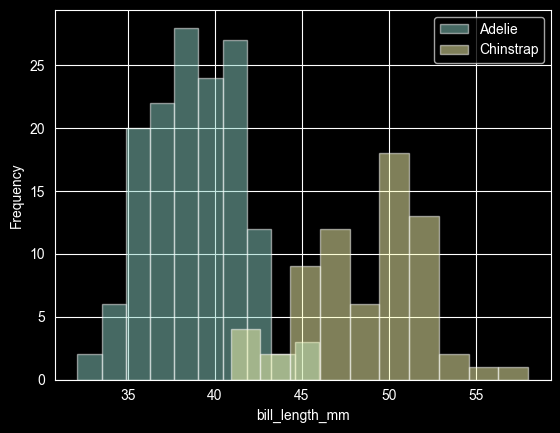

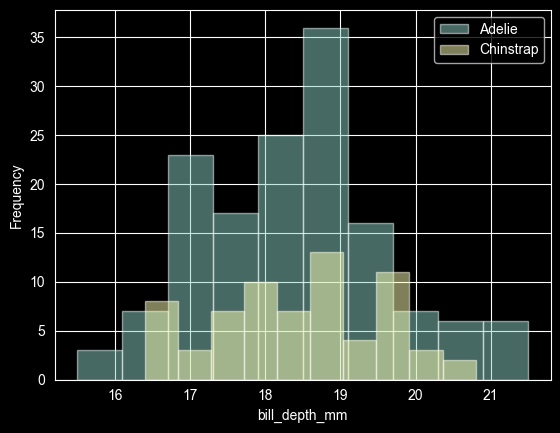

In [5]:
import matplotlib.pyplot as plt

for feature_name in culmen_columns:
    plt.figure()
    penguins.groupby("species")[feature_name].plot.hist(alpha=0.5, legend=True)
    plt.xlabel(feature_name)

From the distributions of the features, we can see that the length of the bill correlates more with one class as it increases or decreases. However, the depth of the bill does not.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    penguins[culmen_columns],
    penguins[target_column],
    random_state=42
)

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_regression = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

logistic_regression.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [8]:
accuracy = logistic_regression.score(
    X_test,
    y_test
)
accuracy

0.9814814814814815

Given this classification problem uses only two features, we can observe the decision function boundary - this is the rule used by the predictive model to affect a class label given the feature values of the sample.

For this ,we use `DecisionBoundaryDisplay`, a tool to plot the decision function boundary in a 2D feature space. In realistic contexts, more than two features would be fit and thus this visualization would not be possible.

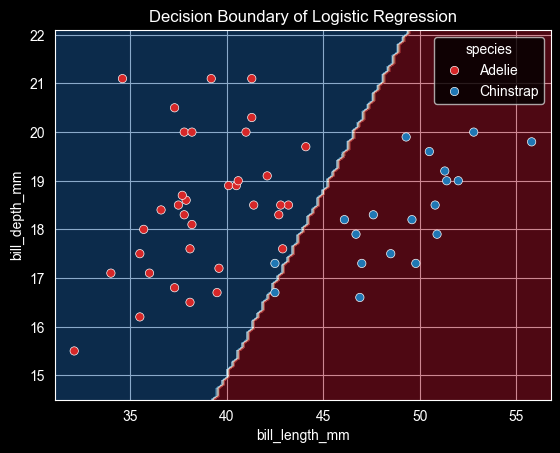

In [16]:
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    logistic_regression,
    X_test,
    response_method="predict",
    cmap="RdBu_r",
    alpha=0.5
)

sns.scatterplot(
    data=pd.concat([X_test, y_test], axis=1),
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column,
    palette=["tab:red", "tab:blue"]
)
_ = plt.title("Decision Boundary of Logistic Regression")

We can now observe the weights of the function.

In [17]:
coefs = logistic_regression[-1].coef_[0]
weights = pd.Series(coefs, index=[f"Weight for '{c}'" for c in culmen_columns])
weights

Weight for 'bill_length_mm'    3.826077
Weight for 'bill_depth_mm'    -1.081607
dtype: float64

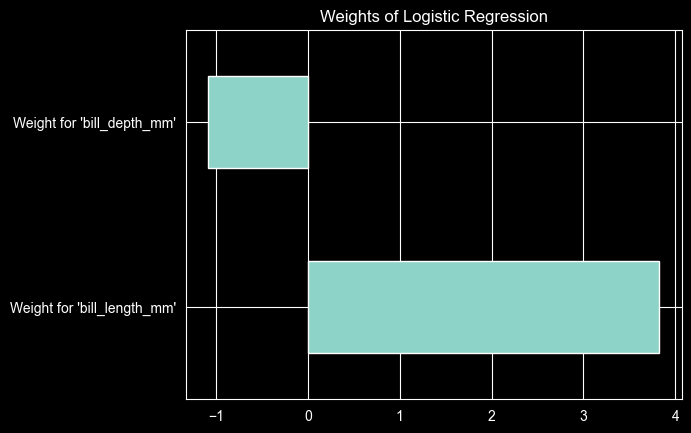

In [18]:
weights.plot.barh()
_ = plt.title("Weights of Logistic Regression")

## Predicted Probabilities
When using `predict` on classification models, we are making a **hard class prediction**. This is predicting the most likely class given a sample.

We can also use `predict_proba`, which provides **soft predictions** as it produces an estimation of the confidence of the target belonging to each class.

In [19]:
y_pred_proba = logistic_regression.predict_proba(X_test)
y_pred_proba

array([[9.99931360e-01, 6.86403050e-05],
       [1.29838728e-02, 9.87016127e-01],
       [9.13652679e-01, 8.63473211e-02],
       [1.24239371e-02, 9.87576063e-01],
       [9.09257622e-01, 9.07423784e-02],
       [9.99177644e-01, 8.22356162e-04],
       [9.90756715e-01, 9.24328470e-03],
       [9.98062807e-01, 1.93719319e-03],
       [5.96456757e-01, 4.03543243e-01],
       [9.92023523e-01, 7.97647664e-03],
       [9.19607299e-02, 9.08039270e-01],
       [1.16379873e-01, 8.83620127e-01],
       [9.96394120e-01, 3.60588038e-03],
       [9.14698107e-01, 8.53018933e-02],
       [4.56882848e-01, 5.43117152e-01],
       [2.45257670e-02, 9.75474233e-01],
       [6.61385765e-03, 9.93386142e-01],
       [9.85253414e-01, 1.47465857e-02],
       [9.73539988e-01, 2.64600118e-02],
       [3.24827222e-02, 9.67517278e-01],
       [9.92506028e-01, 7.49397158e-03],
       [1.22422914e-03, 9.98775771e-01],
       [2.17646830e-02, 9.78235317e-01],
       [8.19924149e-03, 9.91800759e-01],
       [1.676602

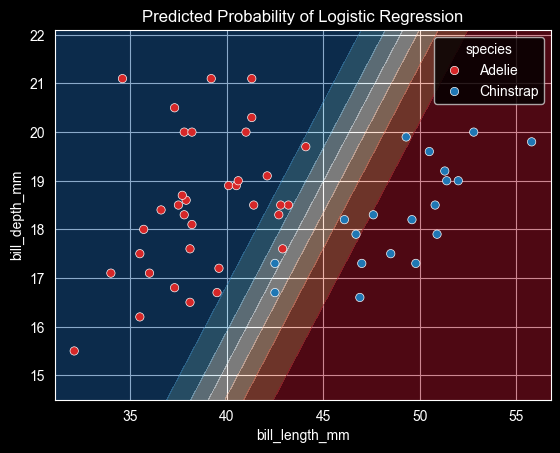

In [20]:
DecisionBoundaryDisplay.from_estimator(
    logistic_regression,
    X_test,
    response_method="predict_proba",
    cmap="RdBu_r",
    alpha=0.5
)

sns.scatterplot(
    data=pd.concat([X_test, y_test], axis=1),
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column,
    palette=["tab:red", "tab:blue"]
)
_ = plt.title("Predicted Probability of Logistic Regression")